# Cross-Generator Evaluation (AP)
This notebook evaluates a binary detector across generators and subdomains and computes Accuracy, Average Precision (AP), and ROC-AUC.

## 1 — Install (optional)
Run this cell in a fresh environment to install required packages.

In [2]:
# !pip install -q timm scikit-learn tqdm torchvision

## 2 — Imports

In [3]:
import os
import glob
import numpy as np
import pandas as pd
from PIL import Image
from tqdm import tqdm

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

import torchvision
from torchvision import transforms
from torchvision.models import resnet50

from sklearn.metrics import accuracy_score, average_precision_score, roc_auc_score
import matplotlib.pyplot as plt

## 3 — Paths (edit as needed)

In [4]:
# Set these paths before running
DATA_ROOT = '/kaggle/input/datasets/marawanmogeb/cv-project-val/Val'  # or local path to Val/
MODEL_PATH = '/kaggle/input/models/marawanmogeb/best-model/pytorch/default/1/resnet50_wang2020.pth'  # or local checkpoint
OUTPUT_DIR = './results'
os.makedirs(OUTPUT_DIR, exist_ok=True)

## 4 — Dataset scanner: builds a dataframe of (generator, subcategory, label, path)

In [5]:
IMAGE_EXTS = ['*.png', '*.jpg', '*.jpeg', '*.bmp', '*.webp']

def collect_images(folder):
    files = []
    for ext in IMAGE_EXTS:
        files.extend(glob.glob(os.path.join(folder, ext)))
    return files

samples = []

for generator in sorted(os.listdir(DATA_ROOT)):
    gen_path = os.path.join(DATA_ROOT, generator)

    if not os.path.isdir(gen_path):
        continue

    direct_real = os.path.join(gen_path, '0_real')

    # Case 1: directly contains 0_real / 1_fake
    if os.path.exists(direct_real):
        for label_name, label in [("0_real", 0), ("1_fake", 1)]:
            folder = os.path.join(gen_path, label_name)
            for img_path in collect_images(folder):
                samples.append({
                    'generator': generator,
                    'subcategory': 'default',
                    'label': label,
                    'path': img_path,
                })
    else:
        # Case 2: contains subcategories
        for subcat in sorted(os.listdir(gen_path)):
            subcat_path = os.path.join(gen_path, subcat)
            if not os.path.isdir(subcat_path):
                continue
            for label_name, label in [("0_real", 0), ("1_fake", 1)]:
                folder = os.path.join(subcat_path, label_name)
                if not os.path.exists(folder):
                    continue
                for img_path in collect_images(folder):
                    samples.append({
                        'generator': generator,
                        'subcategory': subcat,
                        'label': label,
                        'path': img_path,
                    })

df = pd.DataFrame(samples)
print('Total samples:', len(df))
df.head()

Total samples: 22570


,generator,subcategory,label,path
0,biggan,default,0,/kaggle/input/datasets/marawanmogeb/cv-project...
1,biggan,default,0,/kaggle/input/datasets/marawanmogeb/cv-project...
2,biggan,default,0,/kaggle/input/datasets/marawanmogeb/cv-project...
3,biggan,default,0,/kaggle/input/datasets/marawanmogeb/cv-project...
4,biggan,default,0,/kaggle/input/datasets/marawanmogeb/cv-project...


## 5 — Dataset class and transforms

In [6]:
IMG_SIZE = 224
BATCH_SIZE = 64

transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

class DeepfakeDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        image = Image.open(row.path).convert('RGB')
        if self.transform:
            image = self.transform(image)
        label = torch.tensor(row.label).float()
        return image, label

## 6 — Load model (ResNet50 example)

In [7]:
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

model = resnet50(weights=None)

# IMPORTANT: 2 output classes
model.fc = nn.Linear(model.fc.in_features, 2)

checkpoint = torch.load(
    MODEL_PATH,
    map_location=DEVICE,
    weights_only=False
)

state_dict = checkpoint["model_state_dict"]

# Remove DataParallel prefix
clean_state_dict = {
    k.replace("module.", ""): v
    for k, v in state_dict.items()
}

model.load_state_dict(clean_state_dict)

model.to(DEVICE)
model.eval()

print("Model loaded successfully")
print("Best Val AP:", checkpoint.get("best_val_ap"))
print("Test AP:", checkpoint.get("test_ap"))
print("Test Accuracy:", checkpoint.get("test_accuracy"))

Model loaded successfully
Best Val AP: 0.9999935505201386
Test AP: 0.9999929909993283
Test Accuracy: 0.9988333333333334


## 7 — Evaluation function

In [8]:
@torch.no_grad()
def evaluate_subset(sub_df):
    dataset = DeepfakeDataset(sub_df, transform)
    loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

    y_true = []
    y_prob = []

    for images, labels in tqdm(loader, leave=False):
        images = images.to(DEVICE)
        logits = model(images).squeeze(1)
        probs = torch.sigmoid(logits).cpu().numpy()
        y_prob.extend(probs.tolist())
        y_true.extend(labels.numpy().tolist())

    y_true = np.array(y_true)
    y_prob = np.array(y_prob)
    y_pred = (y_prob >= 0.5).astype(int)

    acc = accuracy_score(y_true, y_pred)
    try:
        ap = average_precision_score(y_true, y_prob)
    except:
        ap = np.nan
    try:
        auc = roc_auc_score(y_true, y_prob)
    except:
        auc = np.nan

    return {'accuracy': acc, 'ap': ap, 'auc': auc}

## 8 — Evaluate per generator and save results

In [16]:
@torch.no_grad()
def evaluate_subset(sub_df):

    dataset = DeepfakeDataset(sub_df, transform)

    loader = DataLoader(
        dataset,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=2,
        pin_memory=True,
    )

    y_true = []
    y_prob = []

    for images, labels in tqdm(loader, leave=False):

        images = images.to(DEVICE)

        # logits shape -> [B, 2]
        logits = model(images)

        # probability of fake class
        probs = torch.softmax(logits, dim=1)[:, 1]

        y_prob.extend(probs.cpu().numpy())
        y_true.extend(labels.numpy())

    y_true = np.array(y_true).astype(int)
    y_prob = np.array(y_prob)

    # binary predictions
    y_pred = (y_prob >= 0.5).astype(int)

    acc = accuracy_score(y_true, y_pred)

    try:
        ap = average_precision_score(y_true, y_prob)
    except:
        ap = np.nan

    try:
        auc = roc_auc_score(y_true, y_prob)
    except:
        auc = np.nan

    return {
        "accuracy": acc,
        "ap": ap,
        "auc": auc,
    }

## 9 — Plot AP (paper style)

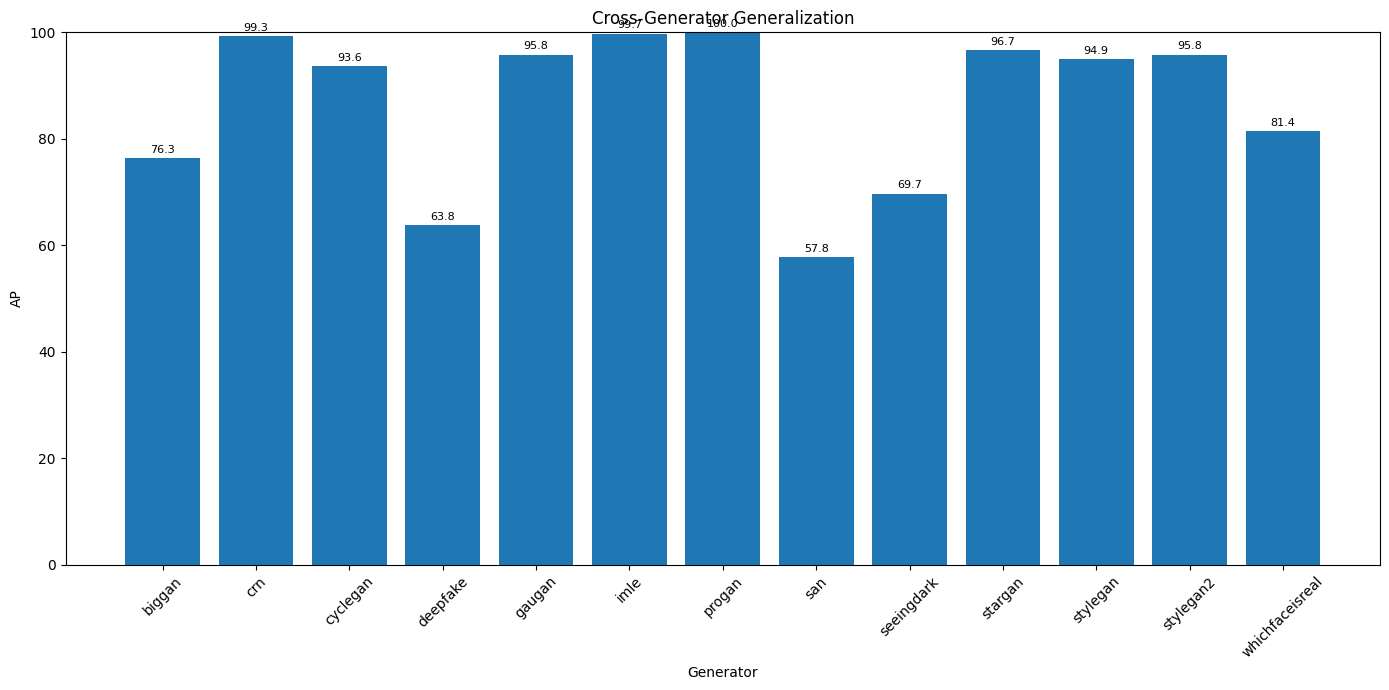

In [22]:
plt.figure(figsize=(14, 7))
x = np.arange(len(results_df))
aps = results_df['ap'].values * 100
plt.bar(x, aps)
plt.xticks(x, results_df.generator, rotation=45)
plt.ylabel('AP')
plt.xlabel('Generator')
plt.title('Cross-Generator Generalization')
plt.ylim(0, 100)
for i, v in enumerate(aps):
    plt.text(i, v + 1, f'{v:.1f}', ha='center', fontsize=8)
plt.tight_layout()
plot_path = os.path.join(OUTPUT_DIR, 'cross_generator_ap.png')
plt.savefig(plot_path, dpi=300)
plt.show()